### Data Visulaization

In [1]:
import sys
import nltk

def check_environment():
    required_libs = ['pandas', 'numpy', 'nltk', 'transformers', 'google_play_scraper', 'textblob', 'vaderSentiment']
    for lib in required_libs:
        if lib not in sys.modules and lib not in globals():
            try:
                __import__(lib)
                print(f' {lib} is installed.')
            except ImportError:
                print(f' {lib} is NOT installed. Please run pip install {lib}.')
    
    # Verify NLTK data
    try:
        nltk.data.find('corpora/stopwords')
        print('NLTK Stopwords found.')
    except LookupError:
        print(' Downloading NLTK Stopwords...')
        nltk.download('stopwords')

check_environment()

 pandas is installed.
 transformers is installed.
 google_play_scraper is installed.
 textblob is installed.
 vaderSentiment is installed.
NLTK Stopwords found.


In [2]:
# Cell 1: Comprehensive Imports
import warnings, re, os, json, sys
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
from wordcloud import WordCloud

print("Environment ready ✓")

Environment ready ✓


In [3]:
import nltk
from nltk.sentiment import SentimentIntensityAnalyzer
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk import word_tokenize, pos_tag
from textblob import TextBlob
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer

nltk.download('punkt')
nltk.download('wordnet')
nltk.download('omw-1.4')
nltk.download('stopwords')

[nltk_data] Downloading package punkt to /home/mine/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package wordnet to /home/mine/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /home/mine/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!
[nltk_data] Downloading package stopwords to /home/mine/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [4]:
import sys
import os

sys.path.insert(0, os.path.abspath('..'))

print('Path set. Python will now look in:', os.path.abspath('..'))


Path set. Python will now look in: /home/mine/10 Academy/fintech-review-analytics


In [5]:
from src.scrape import tokenize_and_lemmatize

In [6]:
# Download necessary NLTK components
for res in ['vader_lexicon', 'stopwords', 'averaged_perceptron_tagger', 'punkt', 'wordnet']:
    nltk.download(res, quiet=True)

sia = SentimentIntensityAnalyzer()
stop_words = set(stopwords.words('english'))

sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (11, 5)

In [7]:
df_raw = pd.read_csv('../data/processed/review_clean.csv')

In [8]:
df_raw.columns

Index(['app', 'review', 'rating', 'date', 'thumbs'], dtype='object')

In [9]:
# Preprocessing using modular logic from src/
print("Running modular preprocessing...")
df_raw['clean_text'] = df_raw['review'].apply(tokenize_and_lemmatize)

# Drop invalid/too short reviews
df_clean = df_raw[df_raw['clean_text'].str.len() > 2].copy()
print(f"Final cleaned dataset size: {len(df_clean)}")


Running modular preprocessing...
Final cleaned dataset size: 1390


Rating & Data Quality Distribution

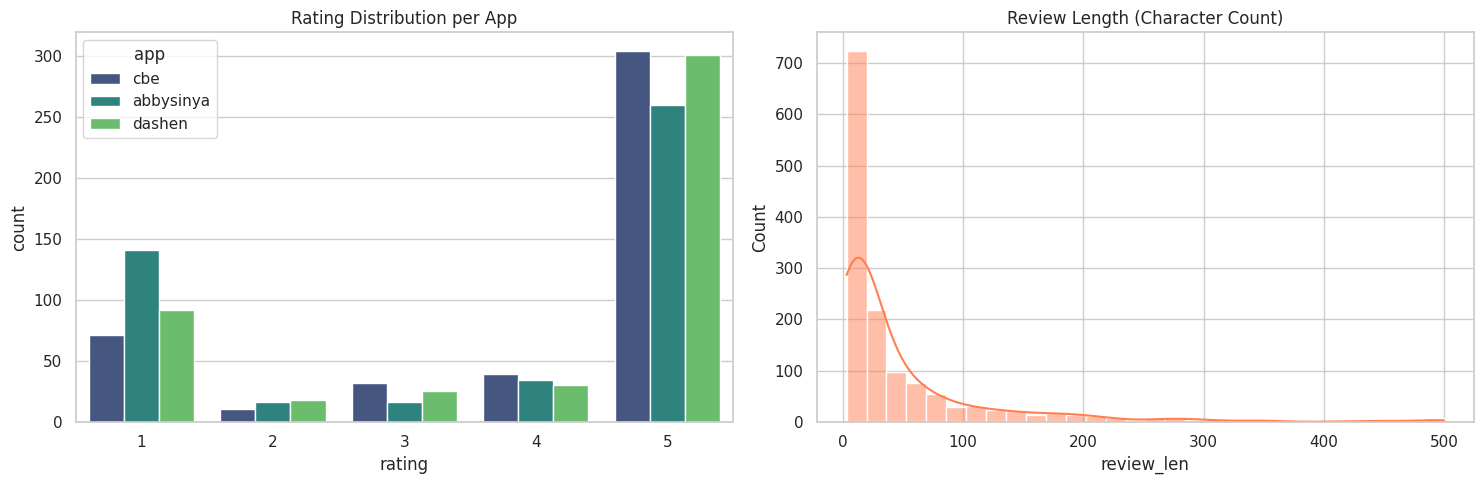

In [10]:
# Visualizing Distributions
fig, ax = plt.subplots(1, 2, figsize=(15, 5))

# Rating per App
sns.countplot(data=df_clean, x='rating', hue='app', palette='viridis', ax=ax[0])
ax[0].set_title('Rating Distribution per App')

# Review Length
df_clean['review_len'] = df_clean['review'].str.len()
sns.histplot(df_clean['review_len'], bins=30, kde=True, ax=ax[1], color='coral')
ax[1].set_title('Review Length (Character Count)')

plt.tight_layout()
plt.savefig('reports/figures/distributions.png')
plt.show()


 NLP Pipeline: Keyword Extraction

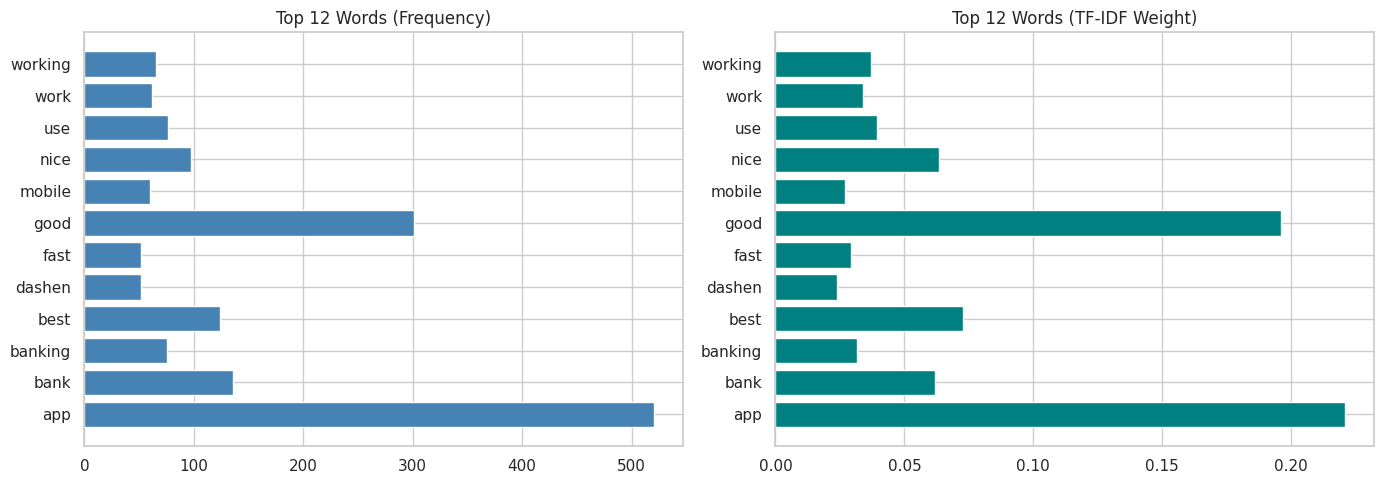

In [11]:

# Frequency (BoW) vs TF-IDF
tfidf_vec = TfidfVectorizer(max_features=12, stop_words='english')
X_tfidf = tfidf_vec.fit_transform(df_clean['review'])

cv_vec = CountVectorizer(max_features=12, stop_words='english')
X_cv = cv_vec.fit_transform(df_clean['review'])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].barh(cv_vec.get_feature_names_out(), X_cv.toarray().sum(axis=0), color='steelblue')
axes[0].set_title('Top 12 Words (Frequency)')

axes[1].barh(tfidf_vec.get_feature_names_out(), X_tfidf.toarray().mean(axis=0), color='teal')
axes[1].set_title('Top 12 Words (TF-IDF Weight)')

plt.tight_layout(); plt.show()

N-gram Analysis (Context Discovery)

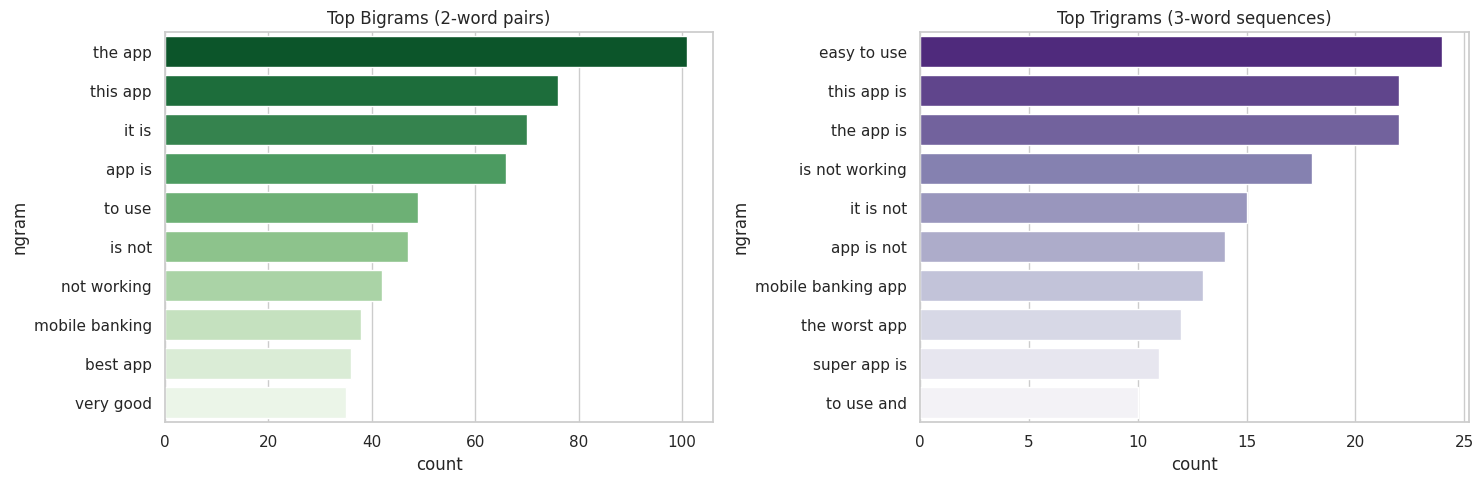

In [12]:

def get_top_ngrams(corpus, n, k=10):
    vec = CountVectorizer(ngram_range=(n,n), max_features=100)
    X = vec.fit_transform(corpus)
    counts = X.sum(axis=0).A1
    return pd.DataFrame({'ngram': vec.get_feature_names_out(), 'count': counts}).sort_values('count', ascending=False).head(k)

bi = get_top_ngrams(df_clean['review'], 2)
tri = get_top_ngrams(df_clean['review'], 3)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
sns.barplot(data=bi, x='count', y='ngram', ax=axes[0], palette='Greens_r')
axes[0].set_title('Top Bigrams (2-word pairs)')
sns.barplot(data=tri, x='count', y='ngram', ax=axes[1], palette='Purples_r')
axes[1].set_title('Top Trigrams (3-word sequences)')
plt.tight_layout(); plt.show()

POS Tagging & Noun Extraction

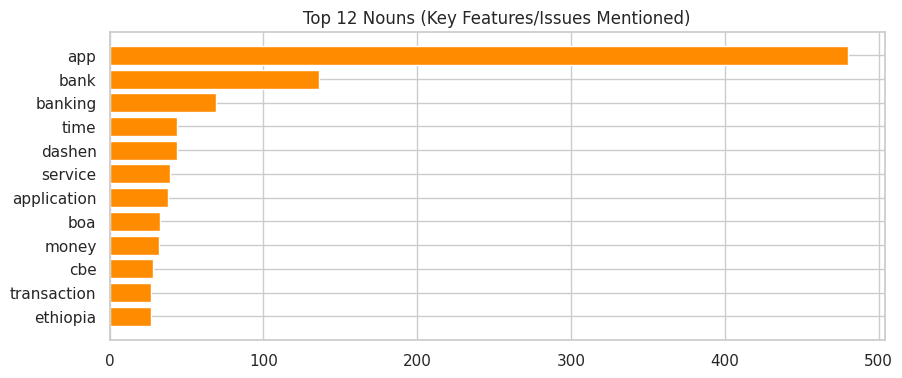

In [13]:
# Identifying Product Features (Nouns)
import nltk
from nltk import word_tokenize, pos_tag
from collections import Counter
import matplotlib.pyplot as plt

try:
    nltk.data.find('taggers/averaged_perceptron_tagger_eng')
except LookupError:
    nltk.download('averaged_perceptron_tagger_eng', quiet=True)

def extract_nouns(text):
    tokens = word_tokenize(text)
    return [w.lower() for w, p in pos_tag(tokens) if p.startswith('NN') and len(w) > 2 and w.lower() not in stop_words]

df_clean['nouns'] = df_clean['review'].apply(extract_nouns)
all_nouns = [n for ns in df_clean['nouns'] for n in ns]
noun_counts = Counter(all_nouns).most_common(12)

plt.figure(figsize=(10, 4))
plt.barh([x[0] for x in noun_counts][::-1], [x[1] for x in noun_counts][::-1], color='darkorange')
plt.title('Top 12 Nouns (Key Features/Issues Mentioned)')
plt.show()

Word Cloud Visualization

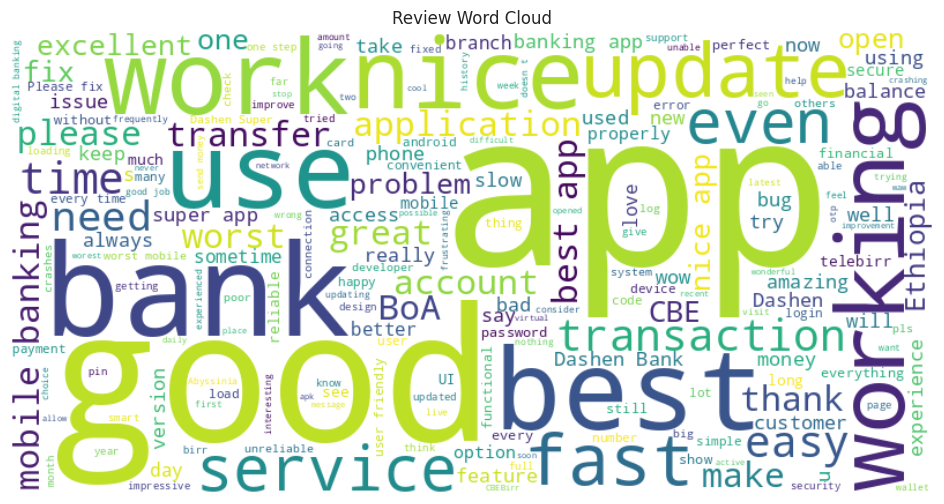

In [14]:
# Word Cloud
text_combined = " ".join(df_clean['review'])
wc = WordCloud(width=800, height=400, background_color='white', colormap='viridis').generate(text_combined)

plt.figure(figsize=(12, 6))
plt.imshow(wc, interpolation='bilinear')
plt.axis('off')
plt.title('Review Word Cloud')
plt.show()

## ulti-Model Sentiment Analysis

### Lexicon Comparison
We use **TextBlob** (Polarity & Subjectivity) and **VADER** (Compound Score).
- **Polarity**: [-1, 1] (Negative to Positive)
- **Subjectivity**: [0, 1] (Fact to Opinion)

In [15]:
# Sentiment Application
df_clean['vader_compound'] = df_clean['review'].apply(lambda x: sia.polarity_scores(x)['compound'])
df_clean['tb_polarity'] = df_clean['review'].apply(lambda x: TextBlob(x).sentiment.polarity)
df_clean['tb_subjectivity'] = df_clean['review'].apply(lambda x: TextBlob(x).sentiment.subjectivity)

def get_label(s):
    return 'positive' if s >= 0.05 else ('negative' if s <= -0.05 else 'neutral')

df_clean['sentiment'] = df_clean['vader_compound'].apply(get_label)
print("VADER Distribution:\n", df_clean['sentiment'].value_counts(normalize=True).round(2))

VADER Distribution:
 sentiment
positive    0.63
neutral     0.22
negative    0.15
Name: proportion, dtype: float64


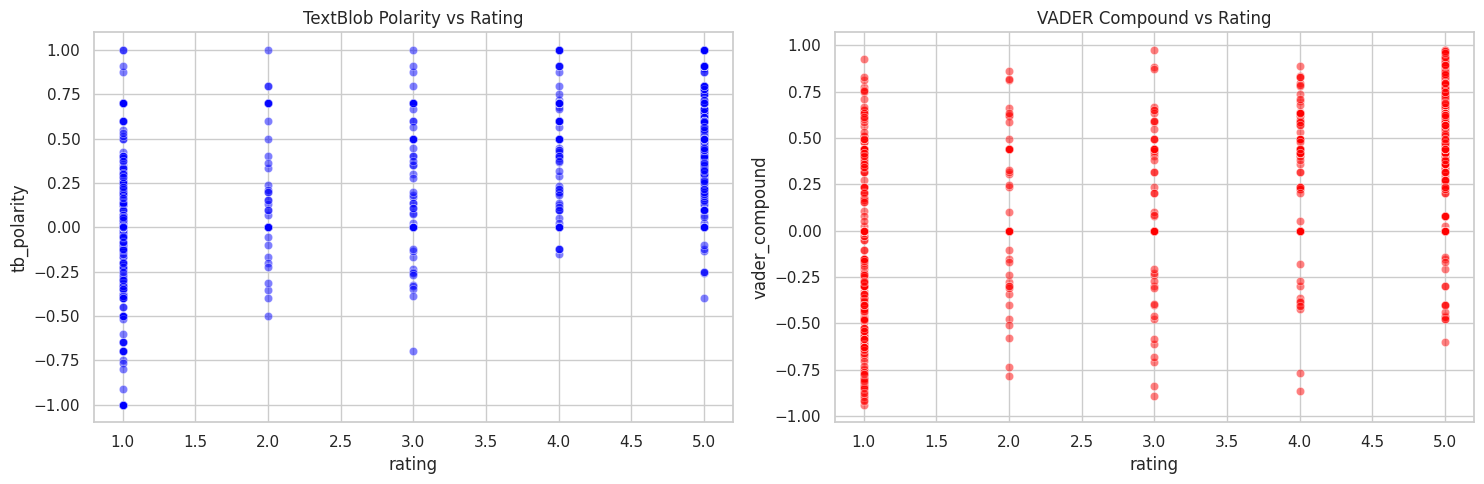

In [16]:
# Sentiment vs. Star Rating
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# TextBlob Scatter
sns.scatterplot(data=df_clean, x='rating', y='tb_polarity', alpha=0.5, ax=axes[0], color='blue')
axes[0].set_title('TextBlob Polarity vs Rating')

# VADER Scatter
sns.scatterplot(data=df_clean, x='rating', y='vader_compound', alpha=0.5, ax=axes[1], color='red')
axes[1].set_title('VADER Compound vs Rating')

plt.tight_layout(); plt.show()

### Transformer-based Sentiment (Template)
Transformers are the gold standard for accuracy.

In [17]:
# Transformer Pipeline
from tqdm.notebook import tqdm

try:
    from transformers import pipeline
    sent_model = pipeline("sentiment-analysis", model="distilbert-base-uncased-finetuned-sst-2-english")

    # Apply transformer to all reviews in df_clean
    transformer_results = []
    # Process in batches to handle memory and speed, if df_clean is very large
    batch_size = 16 # Adjust batch size as needed
    for i in tqdm(range(0, len(df_clean), batch_size), desc="Running Transformer Sentiment"): # Changed desc here
        batch = df_clean['review'].iloc[i:i + batch_size].tolist()
        preds = sent_model(batch)
        transformer_results.extend(preds)

    df_clean['transformer_sentiment_label'] = [p['label'] for p in transformer_results]
    df_clean['transformer_sentiment_score'] = [p['score'] if p['label'] == 'POSITIVE' else -p['score'] for p in transformer_results]

    print("\nTransformer Sentiment Distribution:")
    print(df_clean['transformer_sentiment_label'].value_counts(normalize=True).round(2))

except Exception as e:
    print(f"Transformer skipped: {e}")

Running Transformer Sentiment:   0%|          | 0/87 [00:00<?, ?it/s]


Transformer Sentiment Distribution:
transformer_sentiment_label
POSITIVE    0.64
NEGATIVE    0.36
Name: proportion, dtype: float64


## Section 10.5 — Sentiment Model Comparison: VADER, TextBlob, and Transformer

This section compares the sentiment scores derived from VADER, TextBlob, and the Transformer model. Each model has its strengths and weaknesses:

*   **VADER (Valence Aware Dictionary and sEntiment Reasoner)**: A lexicon- and rule-based sentiment analysis tool specifically attuned to sentiments expressed in social media. It provides a 'compound' score ranging from -1 (most negative) to +1 (most positive).
*   **TextBlob**: A library for processing textual data. It provides 'polarity' (ranging from -1 to +1, similar to VADER's compound score) and 'subjectivity' (ranging from 0 to 1, where 0 is objective and 1 is subjective).
*   **Transformer (DistilBERT fine-tuned on SST-2)**: A state-of-the-art neural network model, leveraging large pre-trained language models. These models often capture more nuanced context and can be more accurate for complex language, but are computationally more intensive.

The comparison aims to highlight agreement and disagreement among these models, helping us understand the robustness of sentiment classification for different review types.

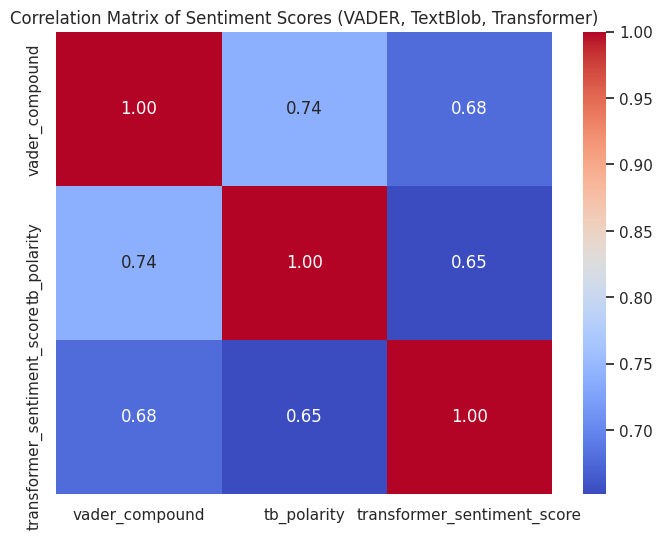

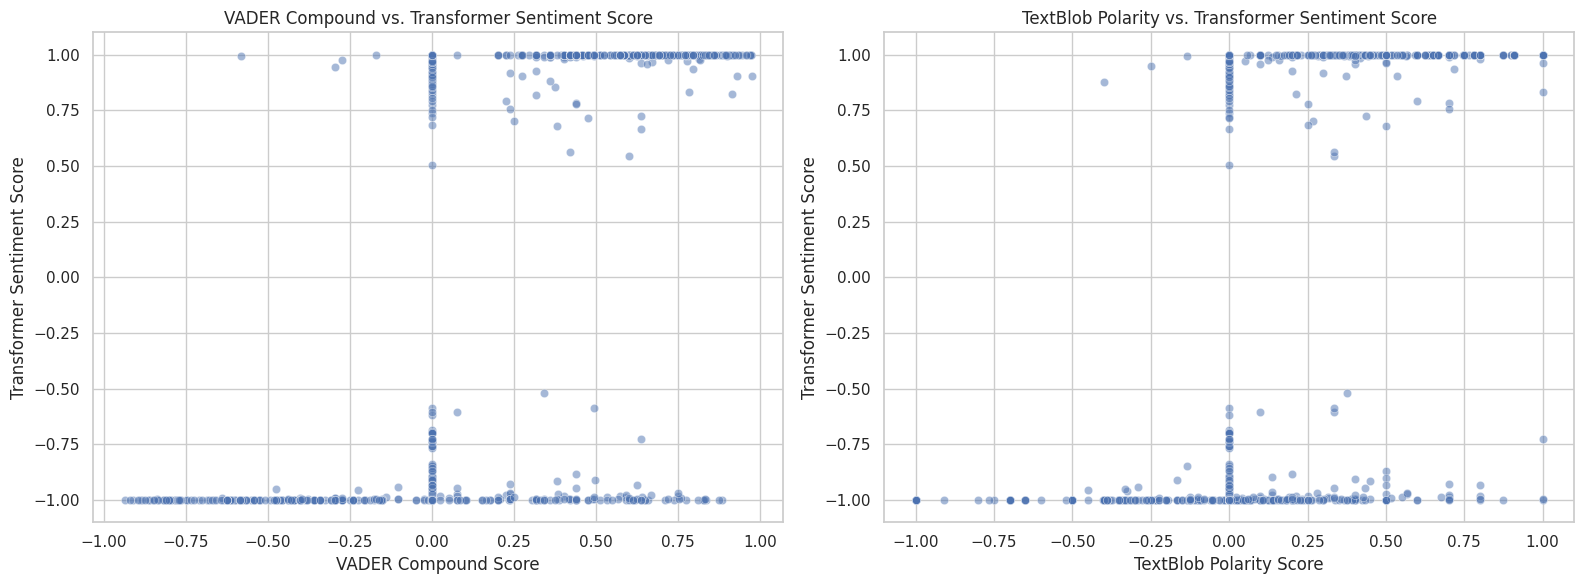

In [18]:
# Visualizing Sentiment Score Correlation

# Ensure transformer_sentiment_score is available
if 'transformer_sentiment_score' not in df_clean.columns:
    print("Transformer sentiment scores not available for comparison.")
else:
    # Create a DataFrame for correlation
    sentiment_scores = df_clean[['vader_compound', 'tb_polarity', 'transformer_sentiment_score']]

    # Calculate the correlation matrix
    correlation_matrix = sentiment_scores.corr()

    plt.figure(figsize=(8, 6))
    sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
    plt.title('Correlation Matrix of Sentiment Scores (VADER, TextBlob, Transformer)')
    plt.show()

    # Plotting scatter plots for pairwise comparison
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))

    sns.scatterplot(data=df_clean, x='vader_compound', y='transformer_sentiment_score', alpha=0.5, ax=axes[0])
    axes[0].set_title('VADER Compound vs. Transformer Sentiment Score')
    axes[0].set_xlabel('VADER Compound Score')
    axes[0].set_ylabel('Transformer Sentiment Score')

    sns.scatterplot(data=df_clean, x='tb_polarity', y='transformer_sentiment_score', alpha=0.5, ax=axes[1])
    axes[1].set_title('TextBlob Polarity vs. Transformer Sentiment Score')
    axes[1].set_xlabel('TextBlob Polarity Score')
    axes[1].set_ylabel('Transformer Sentiment Score')

    plt.tight_layout()
    plt.show()

In [19]:
# Comparing Sentiment Distributions

if 'transformer_sentiment_label' not in df_clean.columns:
    print("Transformer sentiment labels not available for comparison.")
else:
    print("\n--- Sentiment Label Distributions ---")
    print("VADER Distribution:\n", df_clean['sentiment'].value_counts(normalize=True).round(2))
    print("\nTextBlob Polarity Distribution (thresholded at +/-0.05):\n")
    def get_tb_label(s):
        return 'positive' if s >= 0.05 else ('negative' if s <= -0.05 else 'neutral')
    print(df_clean['tb_polarity'].apply(get_tb_label).value_counts(normalize=True).round(2))
    print("\nTransformer Distribution:\n", df_clean['transformer_sentiment_label'].value_counts(normalize=True).round(2))


--- Sentiment Label Distributions ---
VADER Distribution:
 sentiment
positive    0.63
neutral     0.22
negative    0.15
Name: proportion, dtype: float64

TextBlob Polarity Distribution (thresholded at +/-0.05):

tb_polarity
positive    0.64
neutral     0.25
negative    0.11
Name: proportion, dtype: float64

Transformer Distribution:
 transformer_sentiment_label
POSITIVE    0.64
NEGATIVE    0.36
Name: proportion, dtype: float64


## Aggregating Sentiment Scores by App and Star Rating

rating,1,2,3,4,5
app,,,,,
abbysinya,-0.179728,0.055212,0.130938,0.328109,0.374035
cbe,-0.030277,0.240627,-0.052356,0.233833,0.409565
dashen,-0.155179,0.036511,0.294912,0.389890,0.457104


rating,1,2,3,4,5
app,,,,,
abbysinya,-0.105977,0.112909,0.243804,0.422623,0.500680
cbe,0.012485,0.254683,0.181723,0.343767,0.530704
dashen,-0.175189,0.162729,0.199669,0.445383,0.485419


rating,1,2,3,4,5
app,,,,,
abbysinya,-0.827314,-0.563670,-0.258675,0.121218,0.698597
cbe,-0.571821,-0.654702,-0.367995,0.086744,0.780010
dashen,-0.766496,-0.556521,-0.509572,0.455183,0.787976


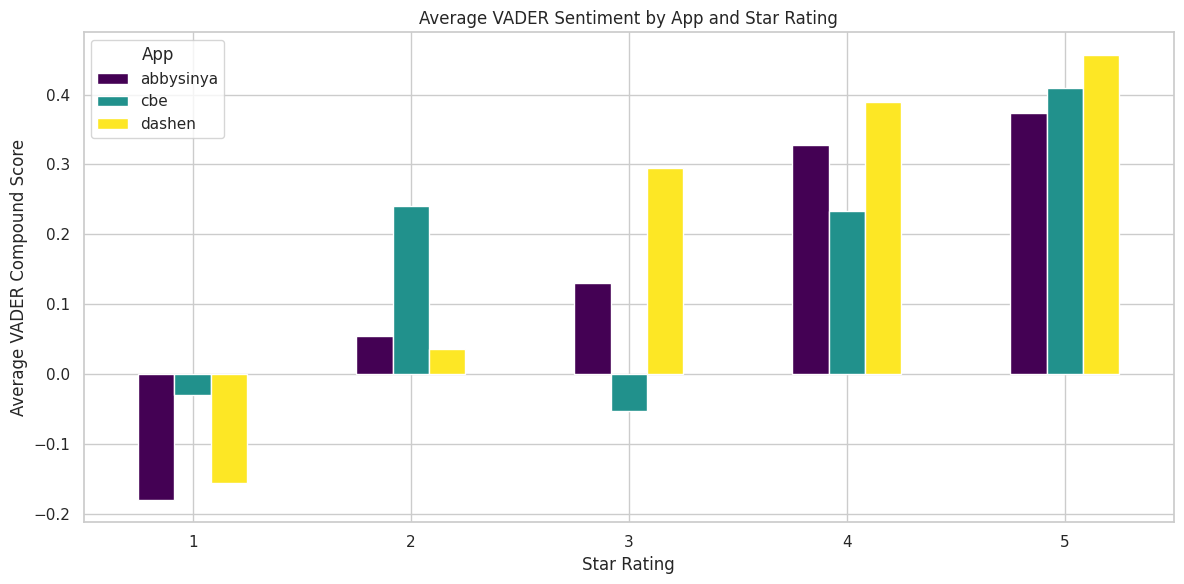

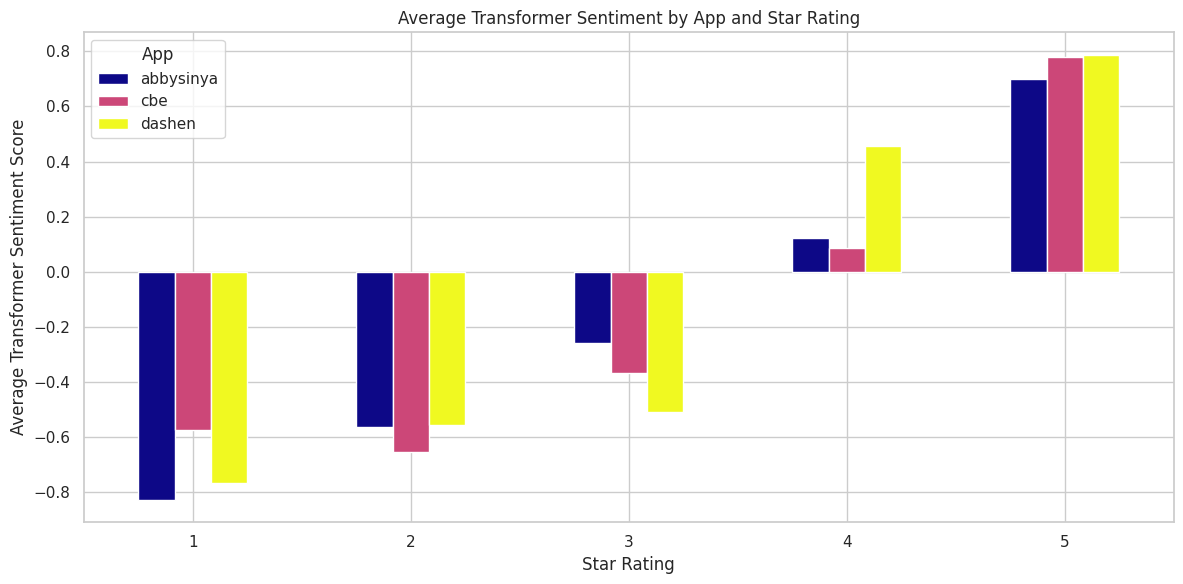

In [20]:
# Aggregate VADER sentiment scores by app and star rating
vader_agg_sentiment = df_clean.groupby(['app', 'rating'])['vader_compound'].mean().unstack()
display(vader_agg_sentiment)

# Aggregate TextBlob polarity scores by app and star rating
tb_agg_sentiment = df_clean.groupby(['app', 'rating'])['tb_polarity'].mean().unstack()
display(tb_agg_sentiment)

# Aggregate Transformer sentiment scores by app and star rating
transformer_agg_sentiment = df_clean.groupby(['app', 'rating'])['transformer_sentiment_score'].mean().unstack()
display(transformer_agg_sentiment)

# Visualize VADER sentiment by app and rating
vader_agg_sentiment.T.plot(kind='bar', figsize=(12, 6), colormap='viridis')
plt.title('Average VADER Sentiment by App and Star Rating')
plt.xlabel('Star Rating')
plt.ylabel('Average VADER Compound Score')
plt.xticks(rotation=0)
plt.legend(title='App')
plt.tight_layout()
plt.show()

# Visualize Transformer sentiment by app and rating
transformer_agg_sentiment.T.plot(kind='bar', figsize=(12, 6), colormap='plasma')
plt.title('Average Transformer Sentiment by App and Star Rating')
plt.xlabel('Star Rating')
plt.ylabel('Average Transformer Sentiment Score')
plt.xticks(rotation=0)
plt.legend(title='App')
plt.tight_layout()
plt.show()

## Section 11 — Thematic Analysis (Actionable Topics)

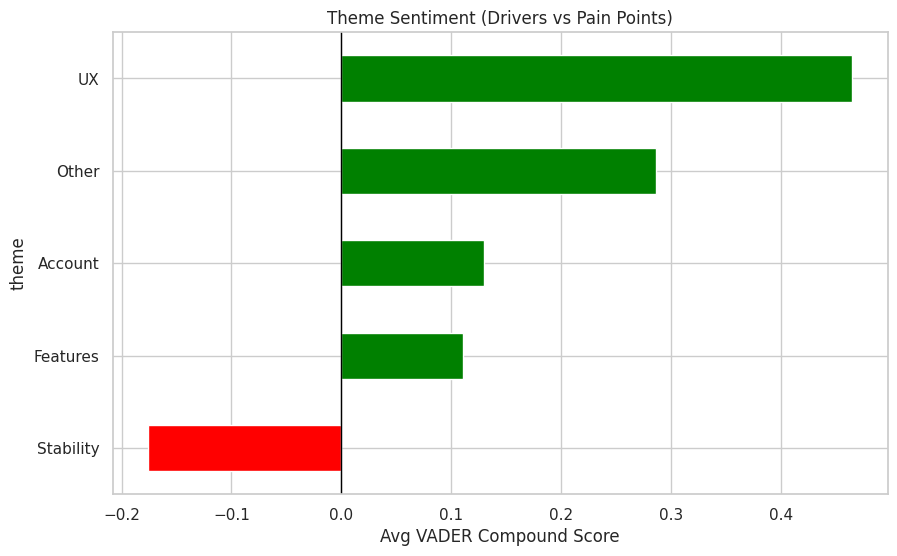

In [21]:
# Cell 12: Business Theme Mapping
THEME_MAP = {
    'Stability': ['crash', 'freeze', 'bug', 'error', 'slow', 'stuck', 'failed'],
    'Account': ['login', 'otp', 'password', 'account', 'verify', 'sign'],
    'UX': ['ui', 'interface', 'clean', 'easy', 'navigation', 'design'],
    'Features': ['transfer', 'payment', 'bill', 'card', 'wallet', 'money']
}

def get_theme(txt):
    txt = txt.lower()
    for theme, keywords in THEME_MAP.items():
        if any(w in txt for w in keywords): return theme
    return 'Other'

df_clean['theme'] = df_clean['review'].apply(get_theme)
theme_sent = df_clean.groupby('theme')['vader_compound'].mean().sort_values()

plt.figure(figsize=(10, 6))
colors = ['red' if x < 0 else 'green' for x in theme_sent.values]
theme_sent.plot(kind='barh', color=colors)
plt.title('Theme Sentiment (Drivers vs Pain Points)')
plt.xlabel('Avg VADER Compound Score')
plt.axvline(0, color='black', lw=1)
plt.show()

## Results Export

In [23]:
# Saving Results
output_cols = ['app', 'review', 'rating', 'sentiment', 'vader_compound', 'theme']
df_final = df_clean[output_cols]

# Save to CSV
df_final.to_csv('../data/processed/fintech_sentiment_analysis_results.csv', index=False)
print("✓ Pipeline results saved as 'fintech_sentiment_analysis_results.csv'")
df_final.head()

✓ Pipeline results saved as 'fintech_sentiment_analysis_results.csv'


,app,review,rating,sentiment,vader_compound,theme
0,cbe,worst,1,negative,-0.6249,Other
1,cbe,this app very full,5,neutral,0.0000,Other
2,cbe,good apps,4,positive,0.4404,Other
4,cbe,this update got crazy i don't know what's goin...,1,positive,0.4767,Other
5,cbe,thanks for you 😘,5,positive,0.4404,Other
